# Necessary Import Functions

In [3]:
import kagglehub
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cuml
from cuml.svm import SVR
from sklearn.preprocessing import StandardScaler
from itertools import product
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

ModuleNotFoundError: No module named 'kagglehub'

# Dataset

In [ ]:
path = kagglehub.dataset_download("szrlee/stock-time-series-20050101-to-20171231")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3


In [ ]:
selected_files = []
for file in glob.glob("/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/*.csv"):
    if "GOOG" in file or "JPM" in file or "IBM" in file or "AAPL" in file or "AMZN" in file:
        selected_files.append(file)

selected_files


['/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/JPM_2006-01-01_to_2018-01-01.csv',
 '/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/GOOGL_2006-01-01_to_2018-01-01.csv',
 '/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/IBM_2006-01-01_to_2018-01-01.csv',
 '/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/AMZN_2006-01-01_to_2018-01-01.csv',
 '/root/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3/AAPL_2006-01-01_to_2018-01-01.csv']

In [ ]:
dfs = []

for filename in selected_files:
    try:
        df = pd.read_csv(filename)
        dfs.append(df)
    except pd.errors.EmptyDataError:
        print(f"Warning: {filename} is empty.")
    except Exception as e:
        print(f"Error processing {filename}: {e}")

if dfs:
    combined_df = pd.concat(dfs, ignore_index=True)
    print("\nCombined DataFrame:")
    print(combined_df.head())
else:
    print("\nNo valid dataframes to combine.")



Combined DataFrame:
         Date   Open   High    Low  Close    Volume Name
0  2006-01-03  39.83  40.36  39.30  40.19  12839400  JPM
1  2006-01-04  39.78  40.14  39.42  39.62  13491800  JPM
2  2006-01-05  39.61  39.81  39.50  39.74   8109400  JPM
3  2006-01-06  39.92  40.24  39.55  40.02   7966900  JPM
4  2006-01-09  39.88  40.72  39.88  40.67  16575200  JPM


In [ ]:
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
print(combined_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15097 entries, 0 to 15096
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    15097 non-null  datetime64[ns]
 1   Open    15095 non-null  float64       
 2   High    15097 non-null  float64       
 3   Low     15095 non-null  float64       
 4   Close   15097 non-null  float64       
 5   Volume  15097 non-null  int64         
 6   Name    15097 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 825.7+ KB
None


In [ ]:
combined_df.shape

(15097, 7)

In [ ]:
combined_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Name'], dtype='object')

In [ ]:
combined_df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.83,40.36,39.30,40.19,12839400,JPM
1,2006-01-04,39.78,40.14,39.42,39.62,13491800,JPM
2,2006-01-05,39.61,39.81,39.50,39.74,8109400,JPM
3,2006-01-06,39.92,40.24,39.55,40.02,7966900,JPM
4,2006-01-09,39.88,40.72,39.88,40.67,16575200,JPM


# Exploratory Data Analysis (EDA)

## Handling Null Values


In [ ]:
print("\nMissing Values in Combined Dataset:")
print(combined_df.isnull().sum())

combined_df_ffill = combined_df.copy()
combined_df_ffill.ffill(inplace=True)
print("\nMissing Values after Forward Fill:")
print(combined_df_ffill.isnull().sum())


Missing Values in Combined Dataset:
Date      0
Open      2
High      0
Low       2
Close     0
Volume    0
Name      0
dtype: int64

Missing Values after Forward Fill:
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
Name      0
dtype: int64


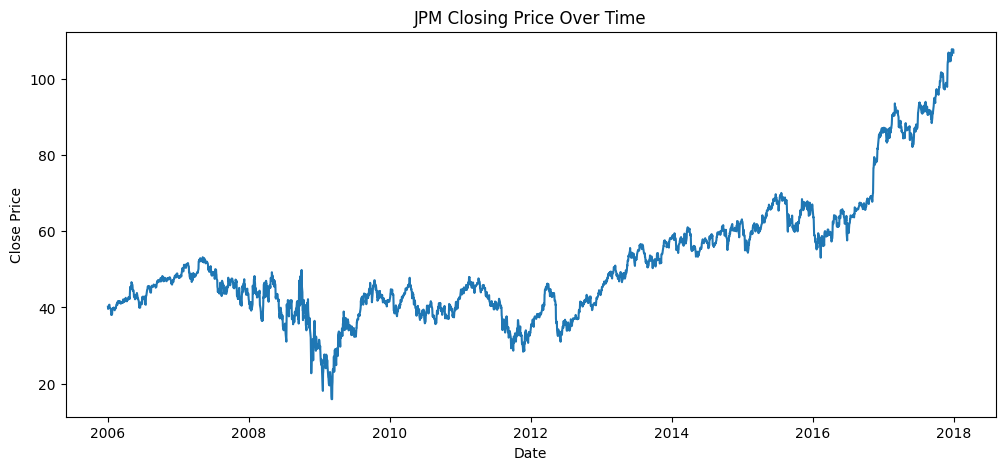

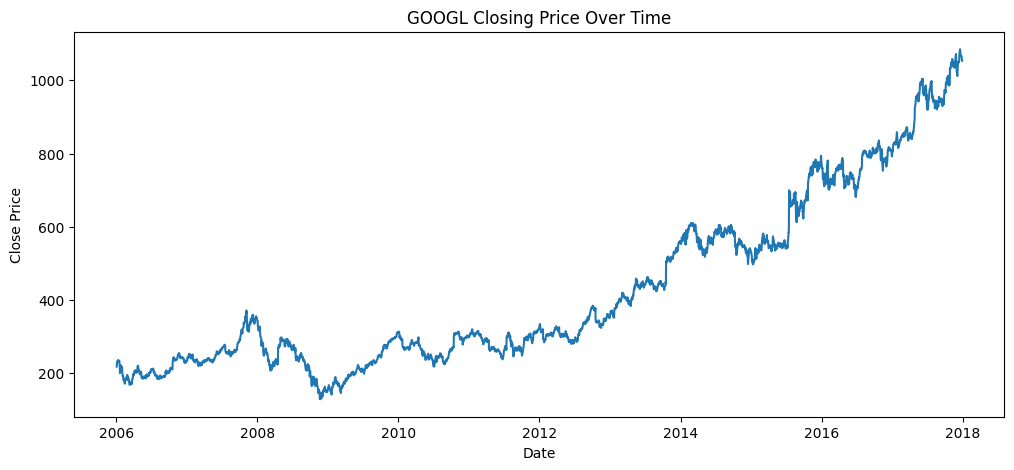

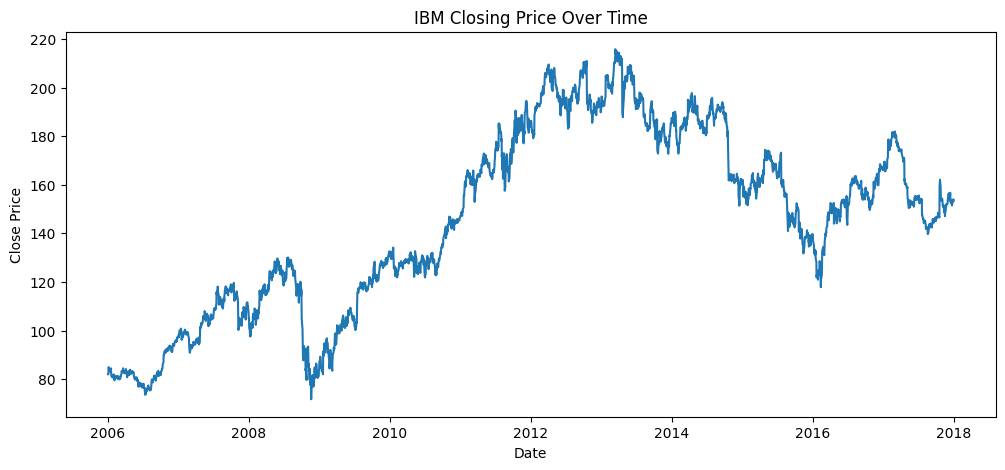

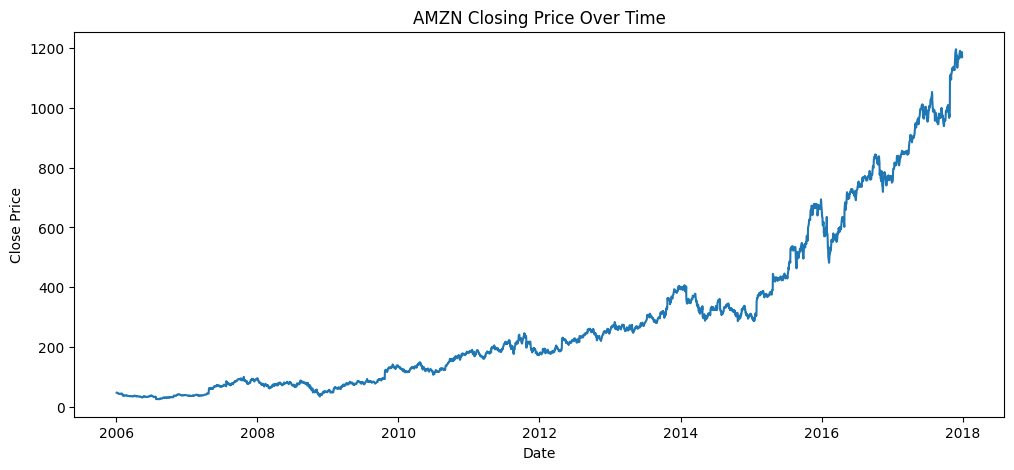

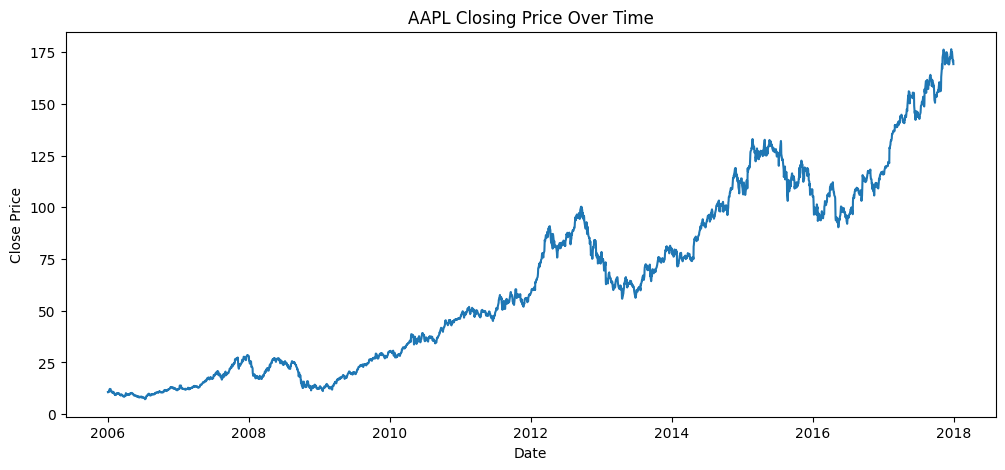

In [ ]:
companies = combined_df_ffill['Name'].unique()

for company in companies:
    company_df = combined_df_ffill[combined_df_ffill['Name'] == company]
    plt.figure(figsize=(12, 5))
    plt.plot(company_df['Date'], company_df['Close'])
    plt.title(f"{company} Closing Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Close Price")
    plt.show()


## Distribution Analysis

In [ ]:
combined_df_ffill.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Name'], dtype='object')

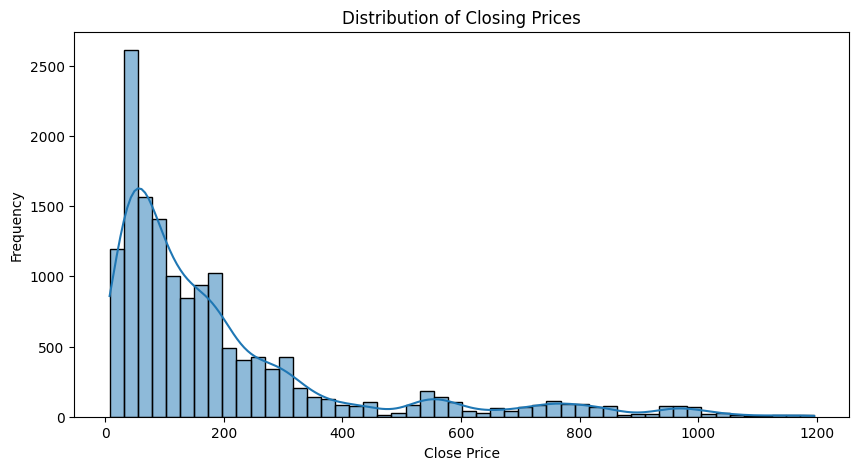

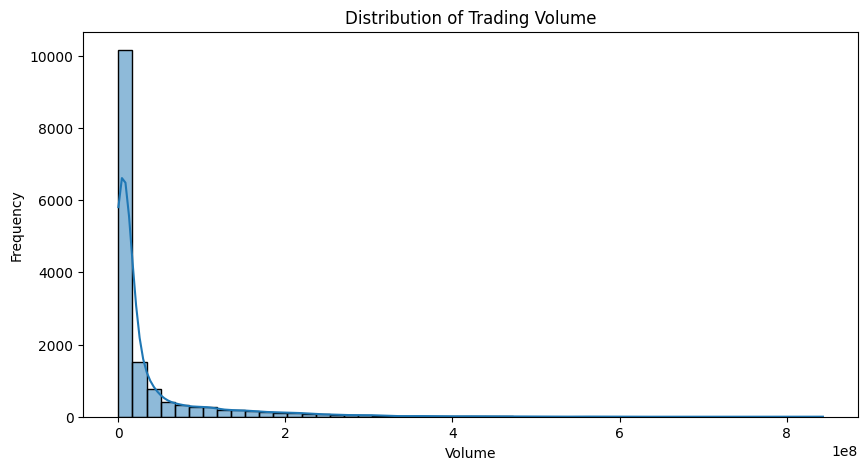

In [ ]:

plt.figure(figsize=(10, 5))
sns.histplot(combined_df_ffill['Close'], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(10, 5))
sns.histplot(combined_df_ffill['Volume'], bins=50, kde=True)
plt.title("Distribution of Trading Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()


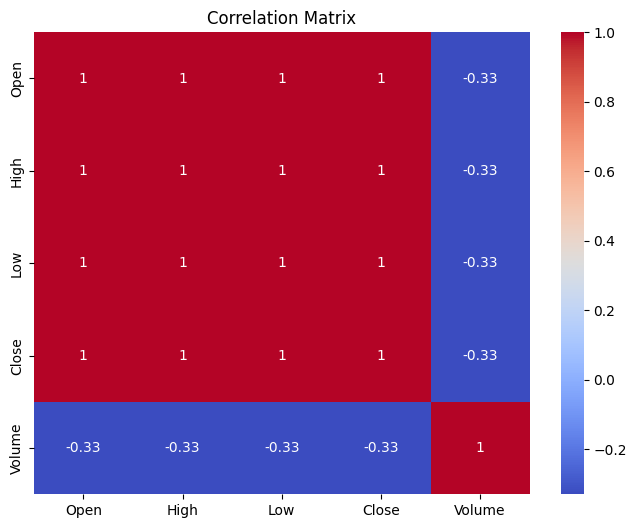

In [ ]:
corr = combined_df_ffill[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


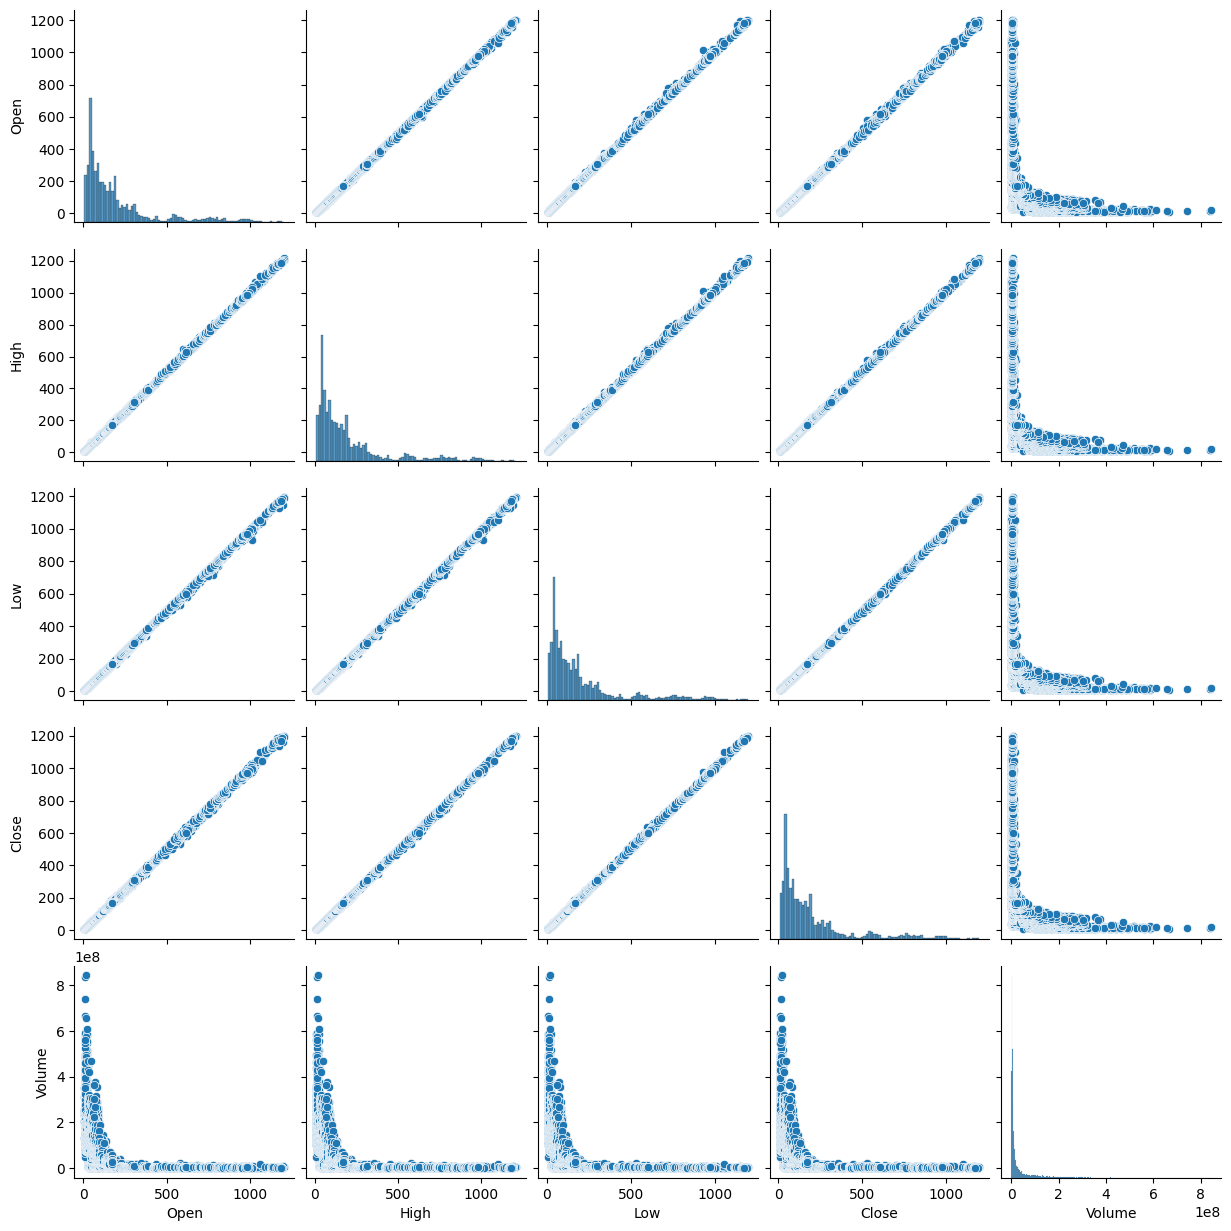

In [ ]:
sns.pairplot(combined_df_ffill[['Open', 'High', 'Low', 'Close', 'Volume']])
plt.show()

In [ ]:
combined_df_ffill.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.83,40.36,39.30,40.19,12839400,JPM
1,2006-01-04,39.78,40.14,39.42,39.62,13491800,JPM
2,2006-01-05,39.61,39.81,39.50,39.74,8109400,JPM
3,2006-01-06,39.92,40.24,39.55,40.02,7966900,JPM
4,2006-01-09,39.88,40.72,39.88,40.67,16575200,JPM


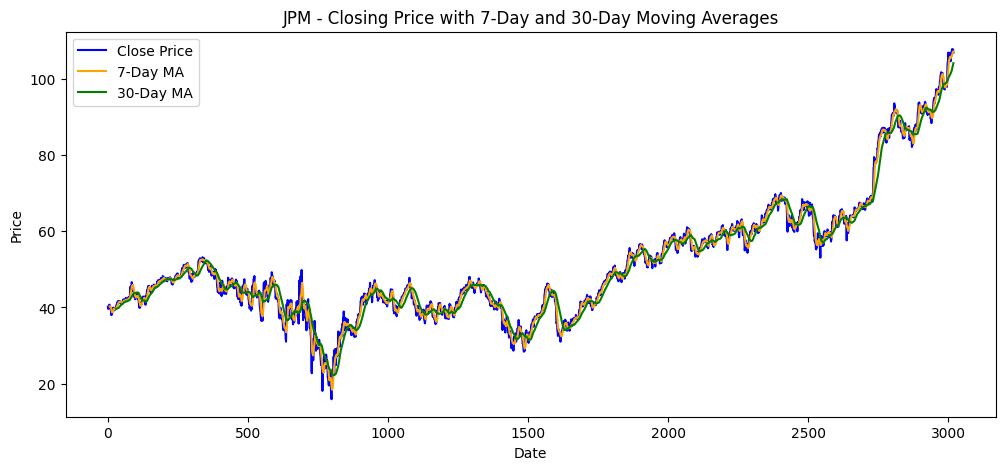

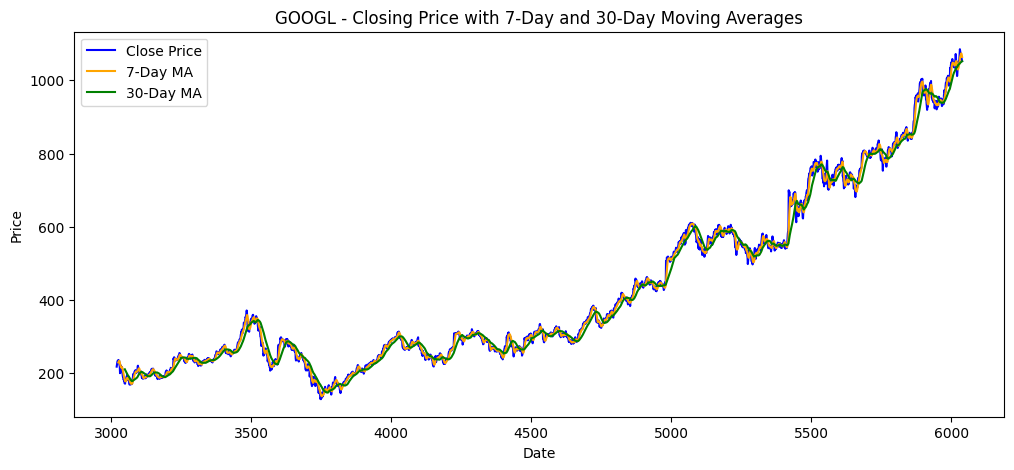

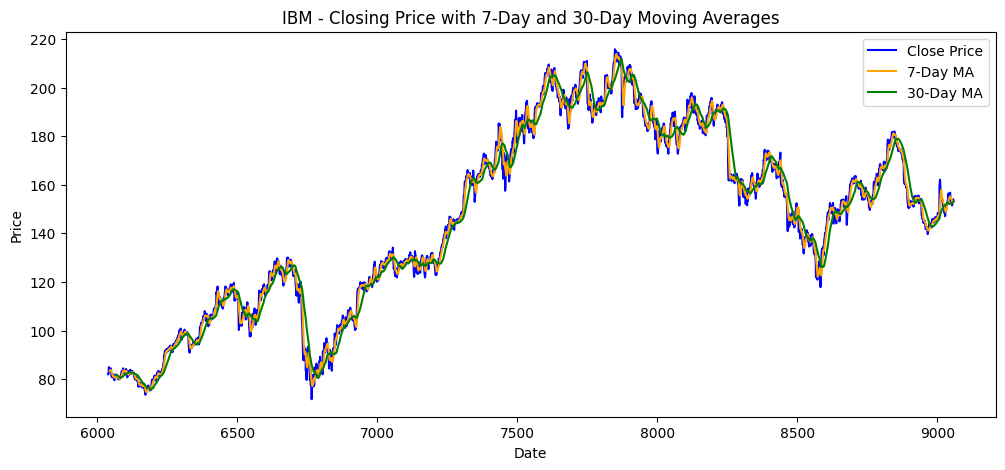

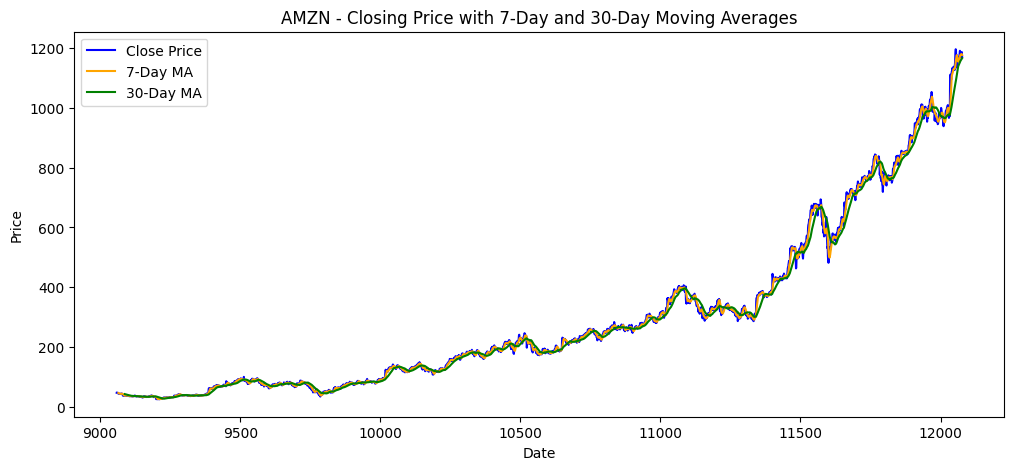

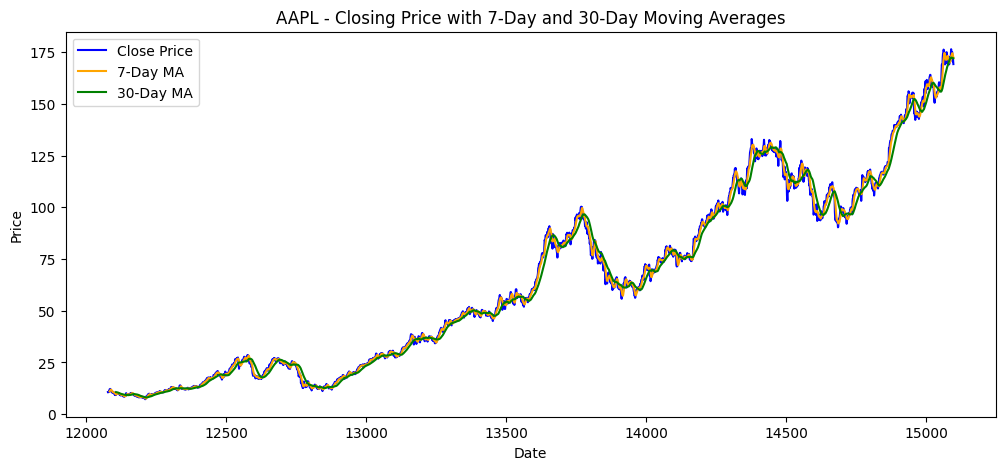

In [ ]:
temp_df = combined_df_ffill.copy()

companies = temp_df['Name'].unique()

for company in companies:
    company_df = temp_df[temp_df['Name'] == company].sort_index()

    ma7 = company_df['Close'].rolling(window=7).mean()
    ma30 = company_df['Close'].rolling(window=30).mean()

    plt.figure(figsize=(12, 5))
    plt.plot(company_df.index, company_df['Close'], label='Close Price', color='blue')
    plt.plot(company_df.index, ma7, label='7-Day MA', color='orange')
    plt.plot(company_df.index, ma30, label='30-Day MA', color='green')
    plt.title(f"{company} - Closing Price with 7-Day and 30-Day Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

In [ ]:
# Load data
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df_ffill = combined_df.copy()
combined_df_ffill.ffill(inplace=True)


In [ ]:
# Feature Engineering
combined_df_ffill = pd.get_dummies(combined_df_ffill, columns=['Name'])
combined_df_ffill['Year'] = combined_df_ffill['Date'].dt.year
combined_df_ffill['Month'] = combined_df_ffill['Date'].dt.month
combined_df_ffill['Day'] = combined_df_ffill['Date'].dt.day
combined_df_ffill['DayOfWeek'] = combined_df_ffill['Date'].dt.dayofweek
combined_df_ffill.drop(columns=['Date'], inplace=True)

In [ ]:

# Define Inputs and Outputs
features = [col for col in combined_df_ffill.columns if col.startswith('Name_')]
X = combined_df_ffill[['Open', 'High', 'Low', 'Volume', 'Year', 'Month', 'Day', 'DayOfWeek'] + features]
y = combined_df_ffill['Close']

In [ ]:
from sklearn.model_selection import KFold, cross_val_score

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# Train Random Forest model with simplified regularization
rf = RandomForestRegressor(
    n_estimators=30,         # More trees to increase stability
    max_depth=6,             # Slightly more depth to improve complexity
    min_samples_split=10,    # Allow more splits to increase model sensitivity
    min_samples_leaf=8,      # Balance complexity with regularization
    max_features='sqrt',     # Maintain variance reduction
    random_state=42
)



# K-Fold Cross-Validation for training
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_mse = -cv_scores.mean()

# Fit the model
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)





Mean Squared Error (Test Set): 102.90
R² Score (Test Set): 1.00
Mean Squared Error (Cross-Validation): 98.75


In [ ]:
# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nMean Squared Error (Test Set): {mse:.2f}')
print(f'R² Score (Test Set): {r2:.2f}')
print(f'Mean Squared Error (Cross-Validation): {cv_mse:.2f}')


Mean Squared Error (Test Set): 102.90
R² Score (Test Set): 1.00
Mean Squared Error (Cross-Validation): 98.75


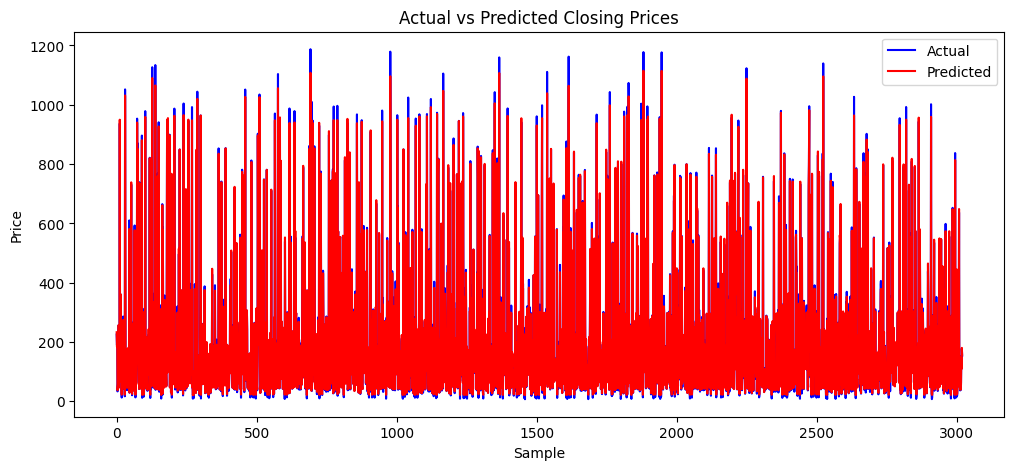

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

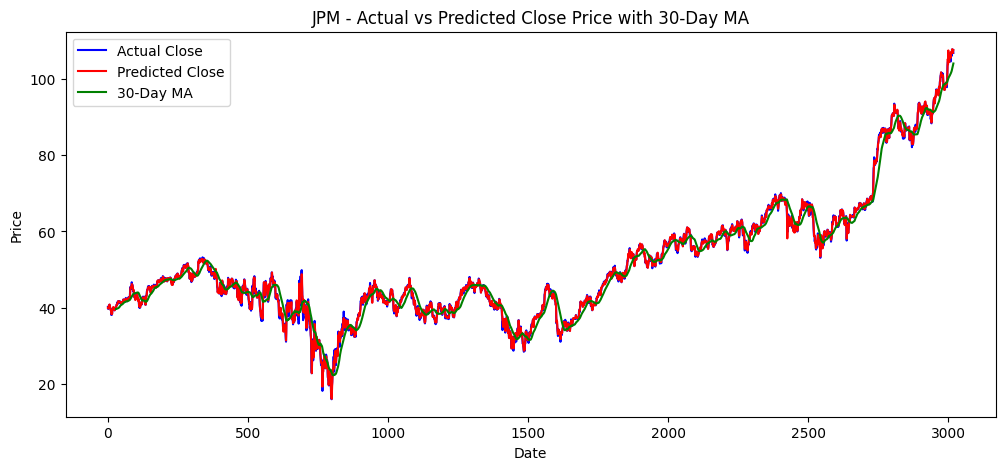

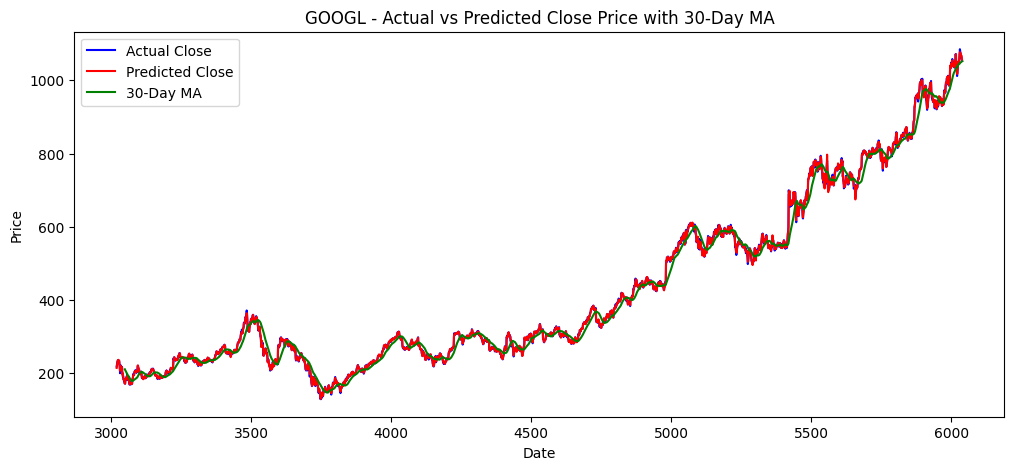

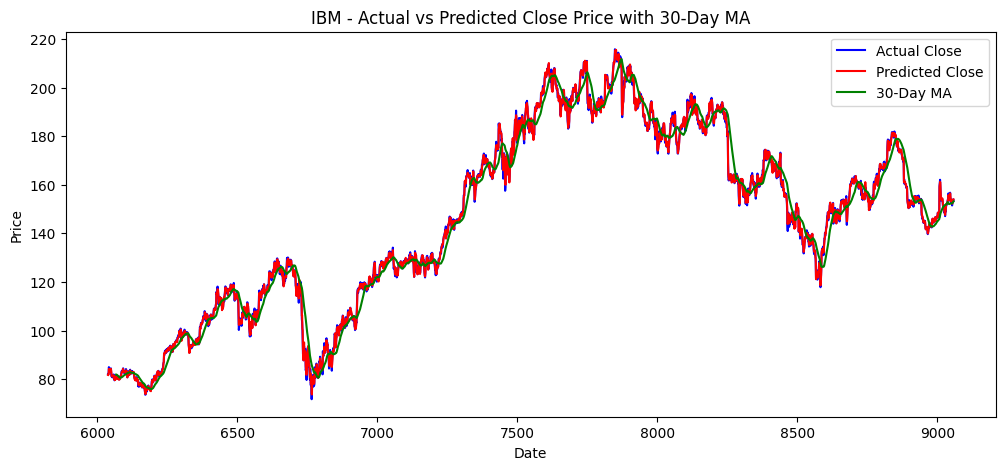

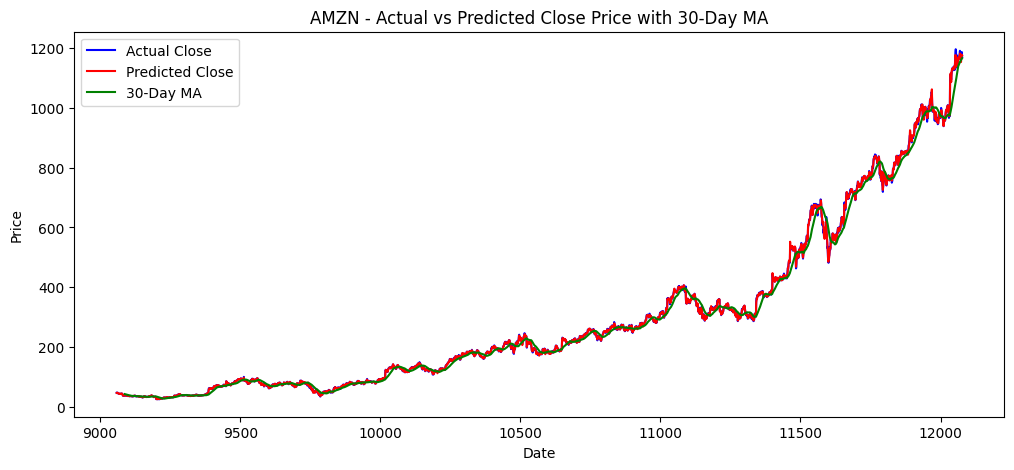

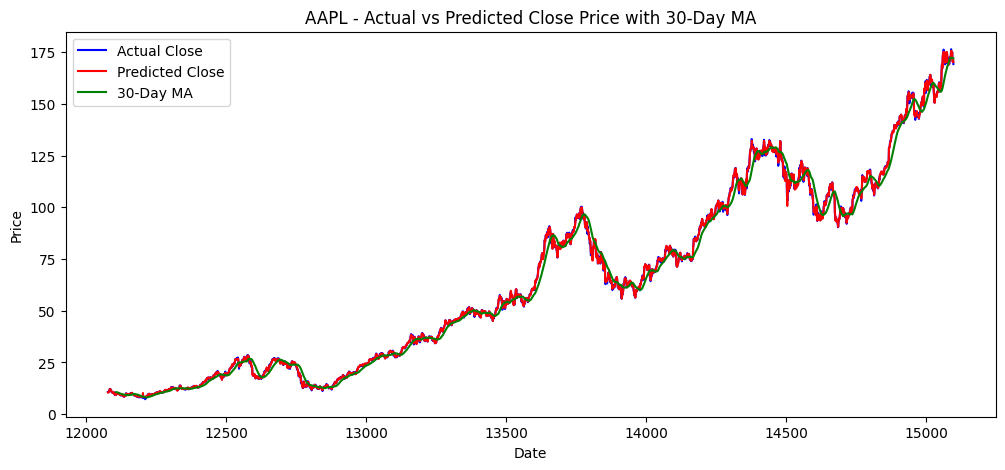

In [ ]:
# Moving Average Comparison
for company in companies:
    company_df = combined_df_ffill[combined_df_ffill[f'Name_{company}'] == 1].copy()
    company_df['Predicted_Close'] = rf.predict(company_df[['Open', 'High', 'Low', 'Volume', 'Year']])

    ma30 = company_df['Close'].rolling(window=30).mean()
    plt.figure(figsize=(12, 5))
    plt.plot(company_df.index, company_df['Close'], label='Actual Close', color='blue')
    plt.plot(company_df.index, company_df['Predicted_Close'], label='Predicted Close', color='red')
    plt.plot(company_df.index, ma30, label='30-Day MA', color='green')
    plt.title(f"{company} - Actual vs Predicted Close Price with 30-Day MA")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

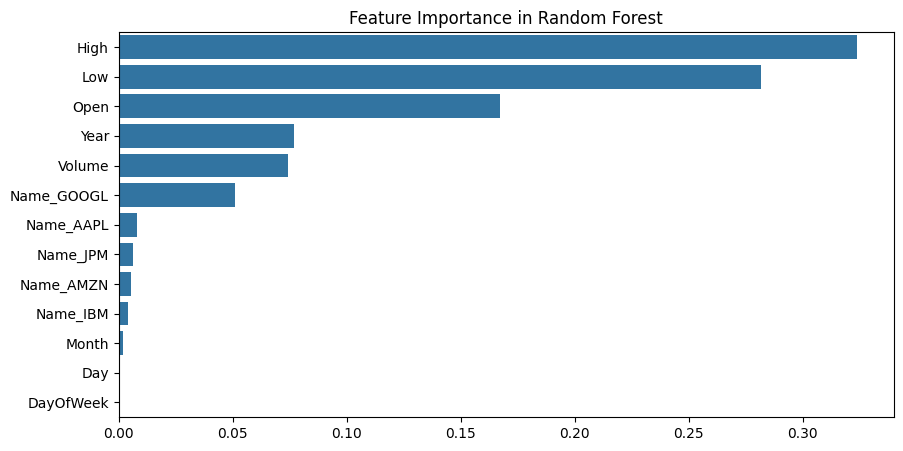

In [ ]:
# Feature Importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[X.columns[i] for i in indices])
plt.title("Feature Importance in Random Forest")
plt.show()

In [ ]:
# Define Inputs and Outputs
important_features = ['Open', 'High', 'Low', 'Volume', 'Year']
X = combined_df_ffill[important_features]
y = combined_df_ffill['Close']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model with regularization parameters
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)

# Fit the model
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Model Evaluation
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

# Cross-Validation Score
cv_mse = -cross_val_score(rf, X, y, cv=5, scoring='neg_mean_squared_error').mean()

print(f'\nMean Squared Error (Test Set): {mse_test:.2f}')
print(f'R² Score (Test Set): {r2_test:.2f}')
print(f'Mean Squared Error (Cross-Validation): {cv_mse:.2f}')


Mean Squared Error (Test Set): 4.92
R² Score (Test Set): 1.00
Mean Squared Error (Cross-Validation): 39.12


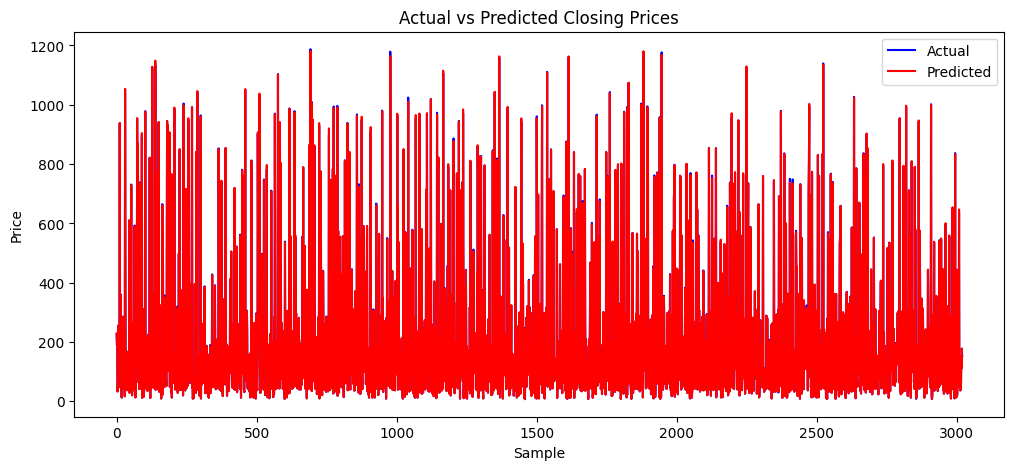

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("Actual vs Predicted Closing Prices")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
print(rf.feature_names_in_)

['Open' 'High' 'Low' 'Volume' 'Year']


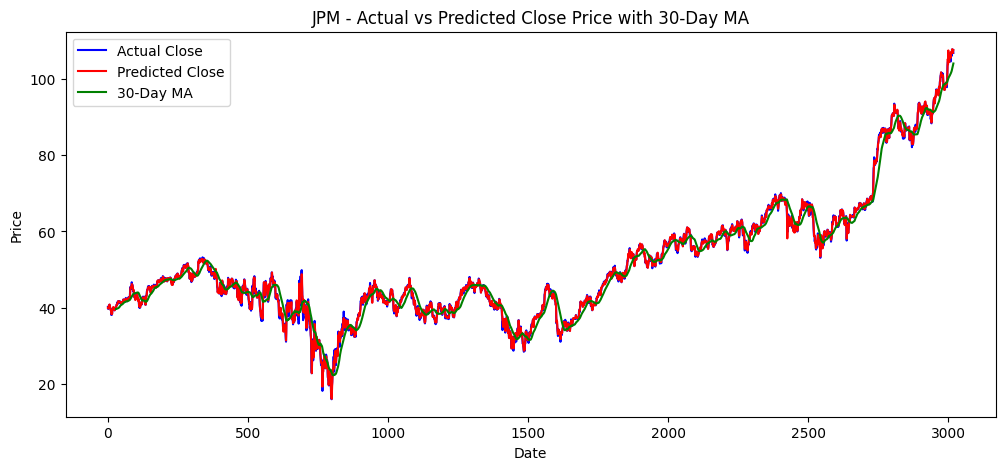

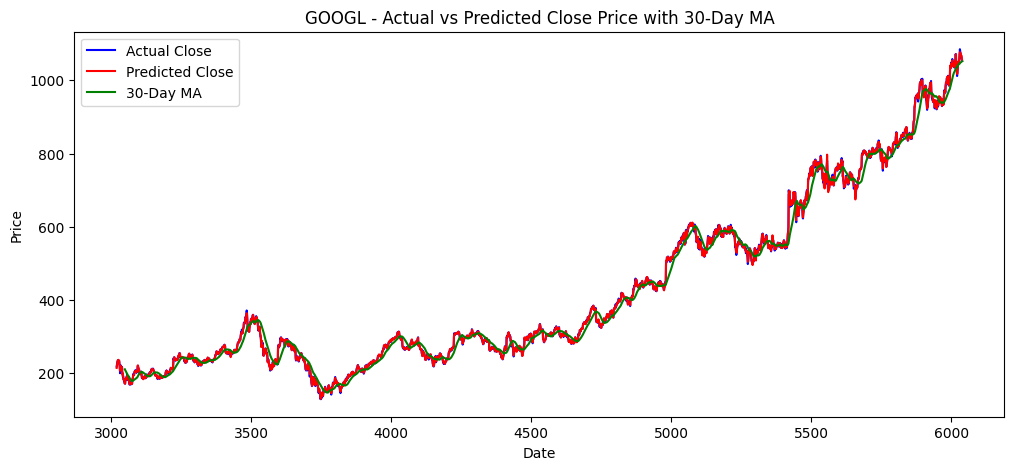

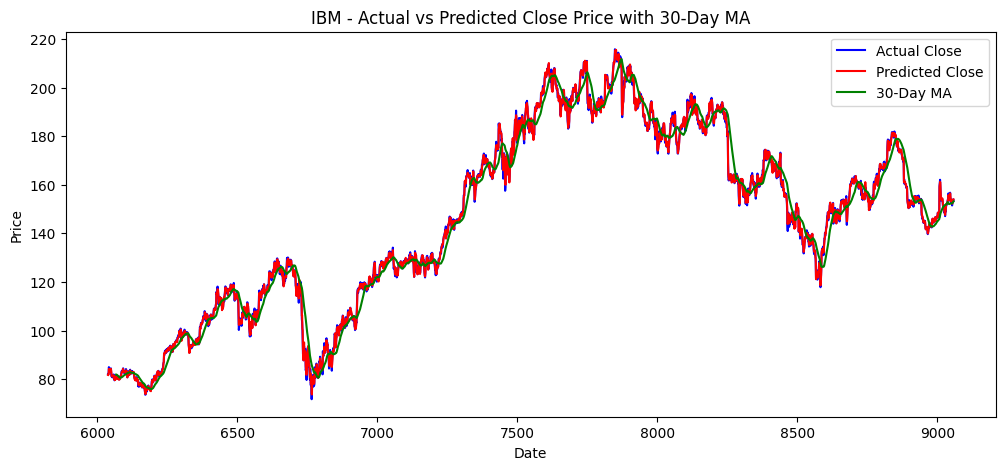

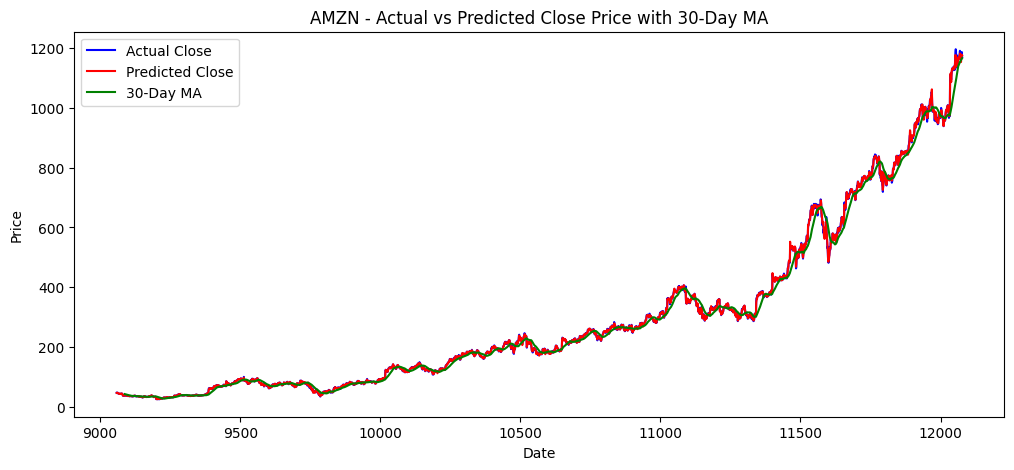

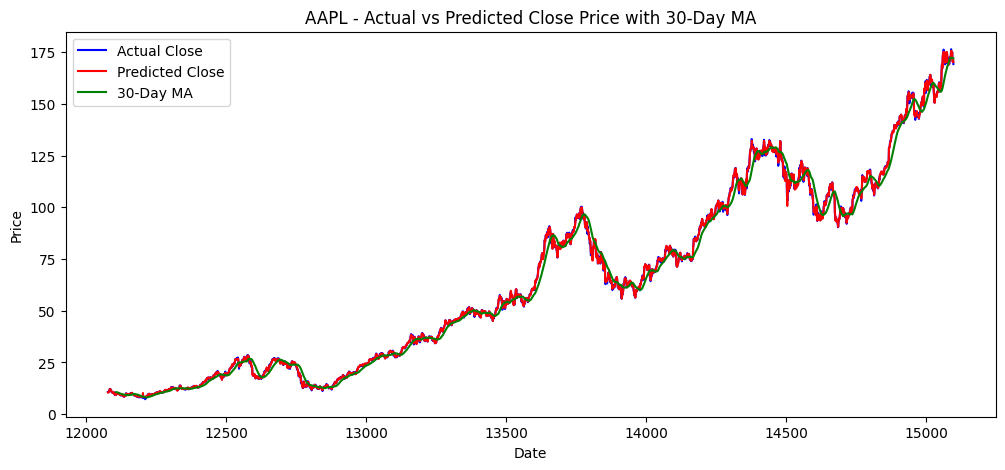

In [ ]:
# Moving Average Comparison
for company in companies:
    company_df = combined_df_ffill[combined_df_ffill[f'Name_{company}'] == 1].copy()
    company_df['Predicted_Close'] = rf.predict(company_df[['Open', 'High', 'Low', 'Volume', 'Year']])

    ma30 = company_df['Close'].rolling(window=30).mean()
    plt.figure(figsize=(12, 5))
    plt.plot(company_df.index, company_df['Close'], label='Actual Close', color='blue')
    plt.plot(company_df.index, company_df['Predicted_Close'], label='Predicted Close', color='red')
    plt.plot(company_df.index, ma30, label='30-Day MA', color='green')
    plt.title(f"{company} - Actual vs Predicted Close Price with 30-Day MA")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# Train Decision Tree model with regularization parameters
dt = DecisionTreeRegressor(
    max_depth=10,             # Control the depth of the tree to prevent overfitting
    min_samples_split=5,      # Minimum samples required to split an internal node
    min_samples_leaf=4,       # Minimum samples required at a leaf node
    random_state=42
)


In [ ]:
# Fit the model
dt.fit(X_train, y_train)

# Predict on test set
y_pred = dt.predict(X_test)

In [ ]:
# Model Evaluation
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

In [ ]:

# Cross-Validation Score
cv_mse = -cross_val_score(dt, X, y, cv=5, scoring='neg_mean_squared_error').mean()

print(f'\nMean Squared Error (Test Set): {mse_test:.2f}')
print(f'R² Score (Test Set): {r2_test:.2f}')
print(f'Mean Squared Error (Cross-Validation): {cv_mse:.2f}')


Mean Squared Error (Test Set): 6.02
R² Score (Test Set): 1.00
Mean Squared Error (Cross-Validation): 33.12


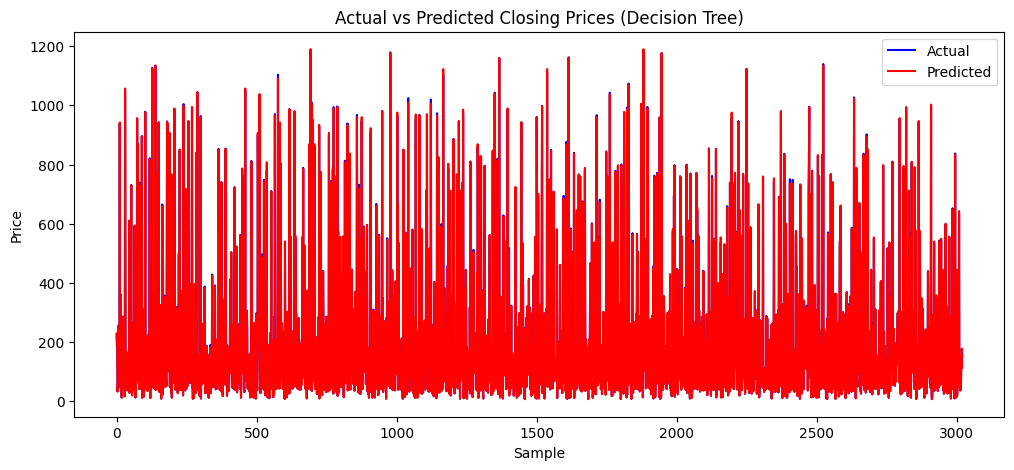

In [ ]:
# Plot Actual vs Predicted
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title("Actual vs Predicted Closing Prices (Decision Tree)")
plt.xlabel("Sample")
plt.ylabel("Price")
plt.legend()
plt.show()

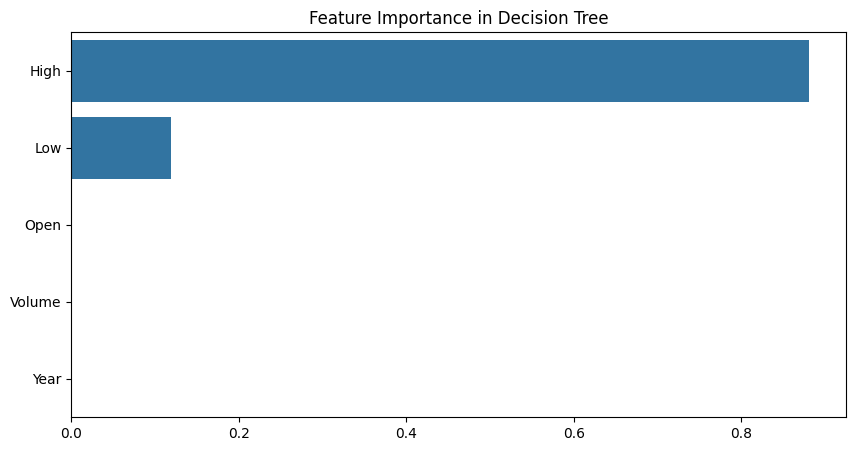

In [ ]:
# Feature Importance
importances = dt.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 5))
sns.barplot(x=importances[indices], y=[X.columns[i] for i in indices])
plt.title("Feature Importance in Decision Tree")
plt.show()

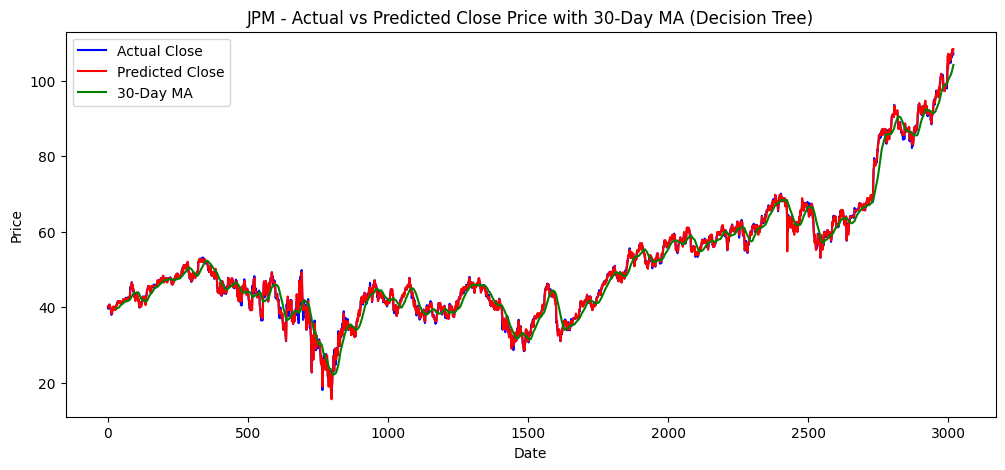

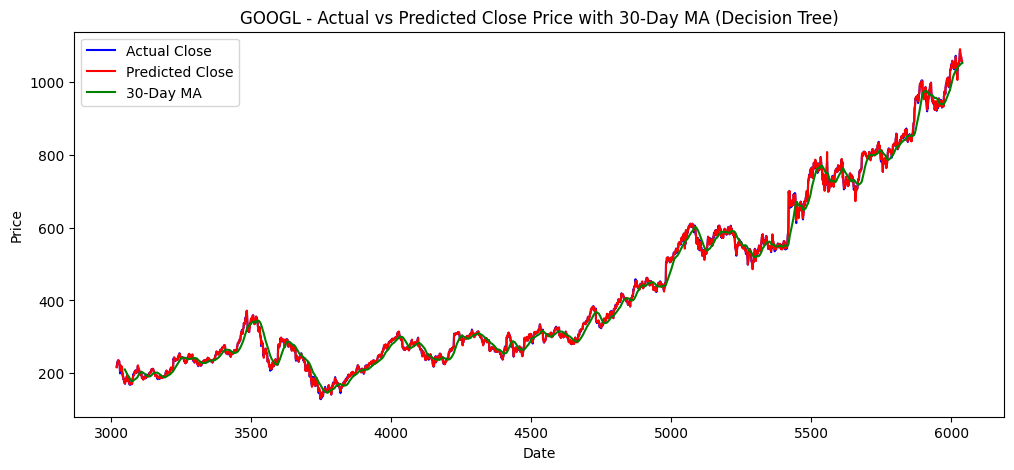

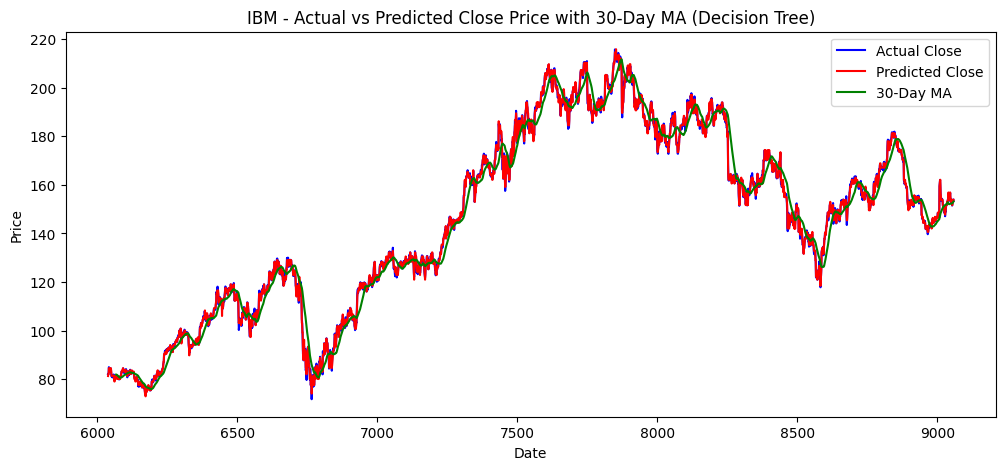

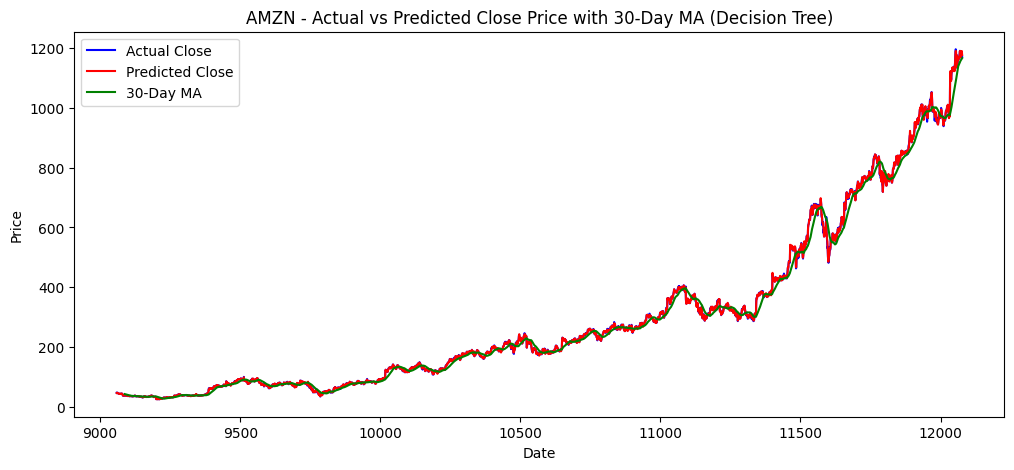

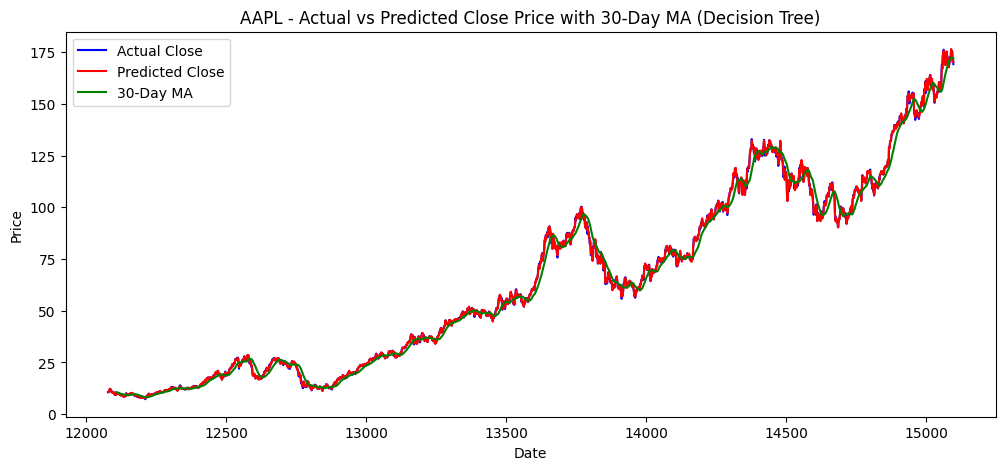

In [ ]:
# Moving Average Comparison
for company in companies:
    company_df = combined_df_ffill[combined_df_ffill[f'Name_{company}'] == 1].copy()
    company_df['Predicted_Close'] = dt.predict(company_df[['Open', 'High', 'Low', 'Volume', 'Year']])

    ma30 = company_df['Close'].rolling(window=30).mean()
    plt.figure(figsize=(12, 5))
    plt.plot(company_df.index, company_df['Close'], label='Actual Close', color='blue')
    plt.plot(company_df.index, company_df['Predicted_Close'], label='Predicted Close', color='red')
    plt.plot(company_df.index, ma30, label='30-Day MA', color='green')
    plt.title(f"{company} - Actual vs Predicted Close Price with 30-Day MA (Decision Tree)")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

In [2]:
import joblib
joblib.dump(rf, "rf_model.pkl")

NameError: name 'rf' is not defined